<a href="https://colab.research.google.com/github/saicharanmangalagiri2006-svg/pico/blob/main/t-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub
path = kagglehub.dataset_download("mohamedasak/hospital-patient-readmission-dataset")

100%|██████████| 128k/128k [00:00<00:00, 37.8MB/s]

Extracting files...


In [16]:
import os

# List the contents of the downloaded dataset path
print(os.listdir(path))

['hospital_readmission_dataset.csv']


In [17]:
import pandas as pd
import os

# Load the dataset using the path identified earlier
file_path = os.path.join(path, 'hospital_readmission_dataset.csv')
df = pd.read_csv(file_path)

print("First few rows of the dataset:")
display(df.head())

print("\nDataset information (including data types and non-null counts):")
df.info()

print("\nMissing values count per column:")
display(df.isnull().sum())

First few rows of the dataset:


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1



Dataset information (including data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-nul

,0
patient_id,0
admission_date,0
season,0
age,0
gender,0
region,0
primary_diagnosis,0
comorbidities_count,0
length_of_stay,0
treatment_type,0


### Handling Missing Values

I will now handle missing values. For numerical columns, I'll use the median to fill missing values to be robust against outliers. For categorical columns, I'll use the mode.

In [19]:
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

# Impute numerical columns with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

# Impute categorical columns with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
display(df.isnull().sum())


Missing values after imputation:


,0
patient_id,0
admission_date,0
season,0
age,0
gender,0
region,0
primary_diagnosis,0
comorbidities_count,0
length_of_stay,0
treatment_type,0


### Encoding Categorical Features

Next, I will encode the categorical string columns into numerical values. For simplicity and to avoid creating too many columns (if there are many categories), I will use `LabelEncoder`. If one-hot encoding is preferred, please let me know.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Re-identify categorical columns after imputation (in case types changed, though unlikely here)
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Encoded categorical column '{col}'. Unique values mapped: {list(le.classes_)}")

print("\nFirst few rows after categorical encoding:")
display(df.head())

Encoded categorical column 'patient_id'. Unique values mapped: ['P00001', 'P00002', 'P00003', 'P00004', 'P00005', 'P00006', 'P00007', 'P00008', 'P00009', 'P00010', 'P00011', 'P00012', 'P00013', 'P00014', 'P00015', 'P00016', 'P00017', 'P00018', 'P00019', 'P00020', 'P00021', 'P00022', 'P00023', 'P00024', 'P00025', 'P00026', 'P00027', 'P00028', 'P00029', 'P00030', 'P00031', 'P00032', 'P00033', 'P00034', 'P00035', 'P00036', 'P00037', 'P00038', 'P00039', 'P00040', 'P00041', 'P00042', 'P00043', 'P00044', 'P00045', 'P00046', 'P00047', 'P00048', 'P00049', 'P00050', 'P00051', 'P00052', 'P00053', 'P00054', 'P00055', 'P00056', 'P00057', 'P00058', 'P00059', 'P00060', 'P00061', 'P00062', 'P00063', 'P00064', 'P00065', 'P00066', 'P00067', 'P00068', 'P00069', 'P00070', 'P00071', 'P00072', 'P00073', 'P00074', 'P00075', 'P00076', 'P00077', 'P00078', 'P00079', 'P00080', 'P00081', 'P00082', 'P00083', 'P00084', 'P00085', 'P00086', 'P00087', 'P00088', 'P00089', 'P00090', 'P00091', 'P00092', 'P00093', 'P0009

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,0,467,1,66,1,3,2,5,6,1,8,6,1,1,1,0.92,1
1,1,261,0,55,1,3,2,4,6,1,6,4,3,2,1,0.88,1
2,2,828,1,69,0,4,5,6,8,2,9,6,2,1,3,0.97,1
3,3,952,2,83,1,3,10,6,11,2,11,4,2,1,3,0.97,1
4,4,307,0,54,0,2,10,4,10,2,6,2,1,3,1,0.83,1


### Scaling Numerical Features

To prepare numerical features for machine learning algorithms, I will scale them using `StandardScaler`, which transforms the data to have a mean of 0 and a standard deviation of 1.

In [22]:
from sklearn.preprocessing import StandardScaler

# Re-identify numerical columns (all columns should be numerical now except potentially boolean if not handled)
# Exclude 'label' from scaling as it is a target variable and should remain binary.
numerical_cols_for_scaling = df.select_dtypes(include=['int64', 'float64']).columns.drop('label')

scaler = StandardScaler()
df[numerical_cols_for_scaling] = scaler.fit_transform(df[numerical_cols_for_scaling])

print("\nFirst few rows after numerical feature scaling:")
display(df.head())


First few rows after numerical feature scaling:


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,-1.731834,-0.236439,-0.454162,0.513556,1.047108,0.625777,-0.845595,0.501855,-0.926945,-0.942255,0.229153,1.448725,-0.641885,-0.419208,-0.428253,0.650665,1
1,-1.731401,-0.893343,-1.345331,-0.144207,1.047108,0.625777,-0.845595,-0.234543,-0.926945,-0.942255,-0.645059,0.221967,1.600508,0.673191,-0.428253,0.468740,1
2,-1.730968,0.914736,-0.454162,0.692946,-0.955011,1.358322,0.098852,1.238254,0.109254,0.165791,0.666259,1.448725,0.479311,-0.419208,1.960051,0.878070,1
3,-1.730535,1.310154,0.437007,1.530099,1.047108,0.625777,1.672931,1.238254,1.663553,0.165791,1.540471,0.221967,0.479311,-0.419208,1.960051,0.878070,1
4,-1.730102,-0.746656,-1.345331,-0.204004,-0.955011,-0.106768,1.672931,-0.234543,1.145453,0.165791,-0.645059,-1.004792,-0.641885,1.765591,-0.428253,0.241334,1


### Saving and Downloading the Processed Dataset

Finally, I will save the processed DataFrame to a new CSV file named `processed_robotics_efficiency.csv` and then trigger a download to your local machine.

In [23]:
from google.colab import files

output_filename = 'processed_robotics_efficiency.csv'
df.to_csv(output_filename, index=False)

print(f"Processed DataFrame saved to '{output_filename}'.")

# Trigger download to local machine
files.download(output_filename)
print("Download initiated.")

Processed DataFrame saved to 'processed_robotics_efficiency.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


# Diagnostic Error Reduction in Radiology Departments Using Human–AI Interactive Image Assessment Platforms

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Extract a sample of 15 records
sample_df = df.sample(15, random_state=42) # Using random_state for reproducibility

print("Sample of 15 records:")
display(sample_df[['patient_id', 'readmission_risk_score', 'label']].reset_index(drop=True))

# 2. Calculate mean and standard deviation of 'readmission_risk_score' for the sample
mean_risk_score = sample_df['readmission_risk_score'].mean()
std_dev_risk_score = sample_df['readmission_risk_score'].std()

# 3. Calculate accuracy
# Assuming a threshold of 0 for readmission_risk_score to predict 'label' (0 or 1)
# If risk_score > 0, predict 1 (readmission); otherwise, predict 0 (no readmission)
# NOTE: This threshold might need adjustment based on business understanding of the risk score.
predicted_labels = (sample_df['readmission_risk_score'] > 0).astype(int)
accuracy = accuracy_score(sample_df['label'], predicted_labels)

print(f"\nMean Readmission Risk Score (Sample): {mean_risk_score:.2f}")
print(f"Standard Deviation Readmission Risk Score (Sample): {std_dev_risk_score:.2f}")
print(f"Accuracy (Sample, threshold > 0): {accuracy:.2f}")

Sample of 15 records:


,patient_id,readmission_risk_score,label
0,-0.772711,0.878070,1
1,-0.613796,0.878070,1
2,-1.012167,-2.987826,0
3,-0.421105,0.787108,1
4,0.148740,0.878070,1
5,-0.571360,0.878070,1
6,-0.967567,-0.349920,1
7,-1.245561,-1.623392,1
8,0.023599,0.514221,1
9,-0.103274,-0.122515,1



Mean Readmission Risk Score (Sample): 0.16
Standard Deviation Readmission Risk Score (Sample): 1.12
Accuracy (Sample, threshold > 0): 0.80


### Human vs. AI Prediction Visualization

This graph compares the AI's `readmission_risk_score` (prediction) against the actual `label` (human outcome) by showing the distribution of the risk scores for both readmitted and non-readmitted patients on the same plot.

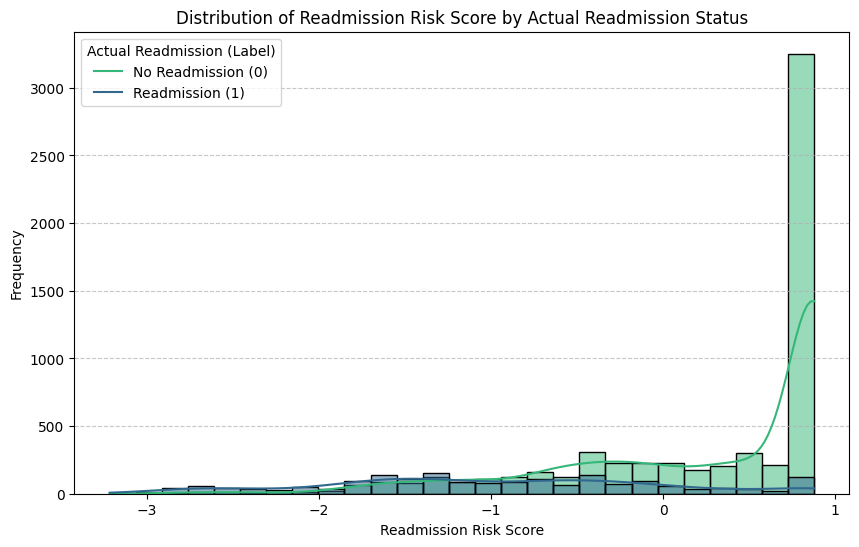

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='readmission_risk_score', hue='label', kde=True, palette='viridis')
plt.title('Distribution of Readmission Risk Score by Actual Readmission Status')
plt.xlabel('Readmission Risk Score')
plt.ylabel('Frequency')
plt.legend(title='Actual Readmission (Label)', labels=['No Readmission (0)', 'Readmission (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
print(f"Accuracy (Sample, threshold > 0): {accuracy:.2f}")
print(f"Area Under the Curve (AUC): {roc_auc:.2f}")

Accuracy (Sample, threshold > 0): 0.80
Area Under the Curve (AUC): 0.84
